In [91]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier,plot_tree
from yellowbrick.classifier import ConfusionMatrix

In [92]:
diamonds = pd.read_csv("diamonds.csv")
diamonds['price'].mean()

3944.80544

In [93]:
diamonds['target'] = np.where(diamonds['price'] <= 4000, '<= 4000', '>4000')
print(np.unique(diamonds['target'], return_counts=True))
# diamonds.columns

x_diamonds = diamonds.iloc[:, 0:10] # Cut, Color e Clarity
y_diamonds = diamonds.iloc[:, 10] # Target

# print(x_diamonds)
# print(y_diamonds)

(array(['<= 4000', '>4000'], dtype=object), array([31984, 18016], dtype=int64))


In [94]:
# Fair < Good < Very Good < Premium < Ideal
cut_order = {
    'Fair': 1,
    'Good': 2,
    'Very Good': 3,
    'Premium': 4,
    'Ideal': 5
}

# J < I < H < G < F < E < D
color_order = {
    'J': 1,
    'I': 2,
    'H': 3,
    'G': 4,
    'F': 5,
    'E': 6,
    'D': 7
}

# I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF
clarity_order = {
    'I1': 1,
    'SI2': 2,
    'SI1': 3,
    'VS2': 4,
    'VS1': 5,
    'VVS2': 6,
    'VVS1': 7,
    'IF': 8
}

# Forma de manipular as ordens
x_diamonds['clarity'] = x_diamonds['clarity'].map(clarity_order)
x_diamonds['cut'] = x_diamonds['cut'].map(cut_order)
x_diamonds['color'] = x_diamonds['color'].map(color_order)

print(np.unique(x_diamonds['cut'], return_counts=True))
print(np.unique(x_diamonds['color'], return_counts=True))
print(np.unique(x_diamonds['clarity'], return_counts=True))

x_diamonds.columns

(array([1, 2, 3, 4, 5], dtype=int64), array([ 1495,  4557, 11204, 12806, 19938], dtype=int64))
(array([1, 2, 3, 4, 5, 6, 7], dtype=int64), array([ 2606,  5058,  7711, 10452,  8864,  9085,  6224], dtype=int64))
(array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int64), array([  688,  8519, 12115, 11404,  7579,  4694,  3369,  1632],
      dtype=int64))


Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [95]:
labelEncoderCut = LabelEncoder()
labelEncoderColor = LabelEncoder()
labelEncoderClarity = LabelEncoder()

x_diamonds.iloc[:, 1] = labelEncoderCut.fit_transform(x_diamonds.iloc[:, 1])
x_diamonds.iloc[:, 2] = labelEncoderColor.fit_transform(x_diamonds.iloc[:, 2])
x_diamonds.iloc[:, 3] = labelEncoderClarity.fit_transform(x_diamonds.iloc[:, 3])

In [96]:
x_diamonds.iloc[0, :]

carat        0.23
cut          4.00
color        5.00
clarity      1.00
depth       61.50
table       55.00
price      326.00
x            3.95
y            3.98
z            2.43
Name: 0, dtype: float64

In [97]:
x_diamonds_treino, x_diamonds_teste, y_diamonds_treino, y_diamonds_teste = train_test_split(x_diamonds, y_diamonds.values, test_size=0.2, random_state=42)

with open('diamonds.pkl', 'wb') as f:
    pickle.dump([x_diamonds_treino, y_diamonds_treino, x_diamonds_teste, y_diamonds_teste], f)

x_diamonds_treino.shape, x_diamonds_teste.shape

((40000, 10), (10000, 10))

In [98]:
naive_diamonds = GaussianNB()
# x_diamonds_treino = x_diamonds_treino.to_numpy()
# x_diamonds_treino

# print(x_diamonds_treino, y_diamonds_treino)
# print(naive_diamonds)

naive_diamonds.fit(x_diamonds_treino, y_diamonds_treino)

print(x_diamonds_teste)

previsoes = naive_diamonds.predict(x_diamonds_teste)
print(previsoes)

       carat  cut  color  clarity  depth  table  price     x     y     z
33553   0.61    1      3        0   61.2   57.2    931  5.44  5.49  3.34
9427    0.91    1      3        4   64.1   60.0   4744  6.11  6.06  3.90
199     0.77    4      2        2   62.2   56.0   2781  5.83  5.88  3.64
12447   1.13    2      1        3   60.7   58.0   5531  6.72  6.75  4.09
39489   0.32    1      2        3   63.1   55.0    505  4.33  4.36  2.74
...      ...  ...    ...      ...    ...    ...    ...   ...   ...   ...
28567   0.30    4      6        4   60.8   58.0    742  4.31  4.34  2.63
25079   0.32    4      4        3   62.4   57.0    645  4.34  4.38  2.72
18707   1.41    3      2        3   61.2   60.0   8654  7.17  7.21  4.40
15200   1.20    2      2        2   62.3   57.0   6569  6.78  6.76  4.22
5857    0.91    3      4        2   61.7   59.0   4036  6.21  6.17  3.82

[10000 rows x 10 columns]
['<= 4000' '>4000' '<= 4000' ... '>4000' '>4000' '>4000']


In [99]:
accuracy_score(y_diamonds_teste, previsoes) #score

0.9426

c:\Users\disrct\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


0.9426

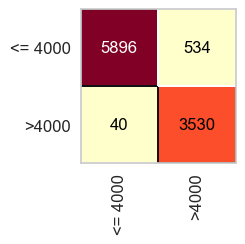

In [100]:
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(naive_diamonds)
cm.fit(x_diamonds_treino, y_diamonds_treino)
cm.score(x_diamonds_teste, y_diamonds_teste)

In [101]:
print(classification_report(y_diamonds_teste, previsoes))

              precision    recall  f1-score   support

     <= 4000       0.99      0.92      0.95      6430
       >4000       0.87      0.99      0.92      3570

    accuracy                           0.94     10000
   macro avg       0.93      0.95      0.94     10000
weighted avg       0.95      0.94      0.94     10000



<h3>arvore de decisão</h3>

In [102]:
with open('diamonds.pkl', 'rb') as f:
    x_diamonds_treino, y_diamonds_treino, x_diamonds_teste, y_diamonds_teste = pickle.load(f)
    
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(x_diamonds_treino, y_diamonds_treino)

DecisionTreeClassifier(max_depth=3)

In [103]:
arvore_diamonds = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_diamonds.fit(x_diamonds_treino, y_diamonds_treino)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [110]:
x_diamonds_treino.shape, y_diamonds_treino.shape

((40000, 10), (40000,))

In [112]:
x_diamonds_teste.shape, y_diamonds_teste.shape

((10000, 10), (10000,))

c:\Users\disrct\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0

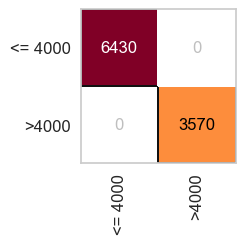

In [113]:
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(arvore_diamonds)
cm.fit(x_diamonds_treino, y_diamonds_treino)
cm.score(x_diamonds_teste, y_diamonds_teste)

In [104]:
previsoes_arvore = arvore_diamonds.predict(x_diamonds_teste)
previsoes_arvore

array(['<= 4000', '>4000', '<= 4000', ..., '>4000', '>4000', '>4000'],
      dtype=object)

In [105]:
accuracy_score(y_diamonds_teste, previsoes_arvore)

1.0

<h3>Radom Forest</h3>

In [107]:
from sklearn.ensemble import RandomForestClassifier

with open('diamonds.pkl', 'rb') as d:
    x_diamonds_treino, y_diamonds_treino, x_diamonds_teste, y_diamonds_teste = pickle.load(d)

In [108]:
random_forest_diamonds = RandomForestClassifier(n_estimators=100, criterion='entropy')
random_forest_diamonds.fit(x_diamonds_treino, y_diamonds_treino)
previsoes_random_forest = random_forest_diamonds.predict(x_diamonds_teste)
accuracy_score(y_diamonds_teste, previsoes_random_forest)

1.0

c:\Users\disrct\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1.0

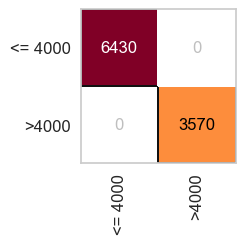

In [109]:
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(random_forest_diamonds)
cm.fit(x_diamonds_treino, y_diamonds_treino)
cm.score(x_diamonds_teste, y_diamonds_teste)

<h3>KNN</h3>